# A/B Testing Data Generator

This module simulates user-level data for an A/B experiment.  
The goal is to generate a realistic dataset that captures how users behave under control and treatment conditions.

The generator models:

- Random assignment of users into control and treatment groups  
- Binary activation outcomes based on predefined conversion rates  
- Continuous session behavior to represent user engagement  

By controlling the underlying parameters (e.g., baseline rates and treatment lift), we create a known “ground truth.”  
This allows us to later evaluate whether statistical methods can correctly detect the impact of a feature.

In [8]:
import numpy as np
import pandas as pd

class ExperimentData:
    def __init__(self, seed=42):
        self.rng = np.random.default_rng(seed)

    def generate(self, n_per_group=1500, baseline_rate=0.22,
                 true_lift=0.08, baseline_sessions=(4.2, 2.1),
                 session_lift=0.9):

        n = n_per_group * 2
        groups = ['control'] * n_per_group + ['treatment'] * n_per_group
        self.rng.shuffle(groups)

        activation_prob = [
            baseline_rate + true_lift if g == 'treatment' else baseline_rate
            for g in groups
        ]
        activated = self.rng.binomial(1, activation_prob)

        mu, sigma = baseline_sessions
        sessions = self.rng.normal(mu, sigma, size=n)
        treat_mask = [g == 'treatment' for g in groups]
        sessions[treat_mask] += session_lift
        sessions = np.maximum(sessions, 0).round(1)

        return pd.DataFrame({
            'user_id': range(n),
            'group': groups,
            'activated': activated,
            'sessions': sessions,
        })

## Generate Sample Data

We now create a synthetic dataset using the experiment generator and inspect basic metrics to verify that the simulation behaves as expected.

In [9]:
gen = ExperimentData()
df = gen.generate()

df.head()
df.groupby("group")[["activated", "sessions"]].mean()

,activated,sessions
group,,
control,0.203333,4.213600
treatment,0.285333,5.175467


## Stage 2: Z-Test — Did Activation Rate Actually Change?
A z-test checks whether the difference in activation rates between 
control and treatment is real, or just random noise.

In [10]:
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

ctrl = df[df['group'] == 'control']
treat = df[df['group'] == 'treatment']

n_ctrl = len(ctrl)
n_treat = len(treat)
x_ctrl = ctrl['activated'].sum()
x_treat = treat['activated'].sum()

z_stat, p_value = proportions_ztest([x_treat, x_ctrl], [n_treat, n_ctrl])

print(f"Control rate:   {x_ctrl/n_ctrl:.4f}")
print(f"Treatment rate: {x_treat/n_treat:.4f}")
print(f"Z-statistic:    {z_stat:.4f}")
print(f"P-value:        {p_value:.4f}")
print(f"Significant:    {p_value < 0.05}")

Control rate:   0.2033
Treatment rate: 0.2853
Z-statistic:    5.2262
P-value:        0.0000
Significant:    True


## Stage 3: T-Test — Did Sessions Change?
Activation is binary (yes/no). Sessions is continuous (a number).
For continuous metrics we use a t-test instead of a z-test.
We also calculate Cohen's d — because a significant p-value doesn't 
tell you if the effect is actually meaningful in practice.

In [11]:
from scipy.stats import ttest_ind

ctrl_sessions = ctrl['sessions']
treat_sessions = treat['sessions']

t_stat, p_value_t = ttest_ind(treat_sessions, ctrl_sessions, equal_var=False)

mean_diff = treat_sessions.mean() - ctrl_sessions.mean()
pooled_std = (((len(ctrl_sessions)-1) * ctrl_sessions.std()**2 +
               (len(treat_sessions)-1) * treat_sessions.std()**2) /
              (len(ctrl_sessions) + len(treat_sessions) - 2)) ** 0.5
cohens_d = mean_diff / pooled_std

print(f"Control mean sessions:   {ctrl_sessions.mean():.4f}")
print(f"Treatment mean sessions: {treat_sessions.mean():.4f}")
print(f"Difference:              {mean_diff:.4f}")
print(f"T-statistic:             {t_stat:.4f}")
print(f"P-value:                 {p_value_t:.4f}")
print(f"Cohen's d:               {cohens_d:.4f}")
print(f"Significant:             {p_value_t < 0.05}")

Control mean sessions:   4.2136
Treatment mean sessions: 5.1755
Difference:              0.9619
T-statistic:             12.6330
P-value:                 0.0000
Cohen's d:               0.4613
Significant:             True


## Stage 4: Chi-Square Test
A second way to test the activation difference.
The z-test compared rates directly. Chi-square tests whether 
group and activation are independent — same question, different angle.
Cramér's V is the effect size equivalent (0 to 1 scale).

In [12]:
from scipy.stats import chi2_contingency
import numpy as np

contingency = pd.crosstab(df['group'], df['activated'])
print("Contingency table:")
print(contingency)

chi2, p_chi, dof, expected = chi2_contingency(contingency)

n = len(df)
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

print(f"\nChi-square stat: {chi2:.4f}")
print(f"P-value:         {p_chi:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"Cramér's V:      {cramers_v:.4f}")
print(f"Significant:     {p_chi < 0.05}")

Contingency table:
activated     0    1
group               
control    1195  305
treatment  1072  428

Chi-square stat: 26.8711
P-value:         0.0000
Degrees of freedom: 1
Cramér's V:      0.0946
Significant:     True


## Stage 5: Sequential Monitoring with O'Brien-Fleming Boundaries
In practice you can't wait until the experiment ends to check results.
But checking early inflates false positives — if you stop as soon as 
p < 0.05 you'll get fooled by random noise.

O'Brien-Fleming boundaries solve this by requiring much stronger 
evidence early in the experiment, relaxing only as data accumulates.

In [15]:
from scipy.stats import norm

def obf_sequential(df, n_looks=10, alpha=0.05):
    n_total = len(df)
    z_crit = norm.ppf(1 - alpha/2)
    results = []

    for look in range(1, n_looks + 1):
        fraction = look / n_looks
        n_current = int(n_total * fraction)
        df_current = df.iloc[:n_current]

        ctrl_c = df_current[df_current['group'] == 'control']
        treat_c = df_current[df_current['group'] == 'treatment']

        x_c = ctrl_c['activated'].sum()
        x_t = treat_c['activated'].sum()
        n_c = len(ctrl_c)
        n_t = len(treat_c)

        p_c = x_c / n_c if n_c > 0 else 0
        p_t = x_t / n_t if n_t > 0 else 0
        p_pool = (x_c + x_t) / (n_c + n_t)
        se = np.sqrt(p_pool * (1 - p_pool) * (1/n_c + 1/n_t))
        z = abs((p_t - p_c) / se) if se > 0 else 0

        boundary = z_crit * np.sqrt(n_looks / look)

        results.append({
            'look': look,
            'pct_enrolled': f"{fraction*100:.0f}%",
            'z_stat': round(z, 3),
            'boundary': round(boundary, 3),
            'crossed': z > boundary
        })

    return pd.DataFrame(results)

seq_results = obf_sequential(df)
print(seq_results.to_string(index=False))

 look pct_enrolled  z_stat  boundary  crossed
    1          10%   2.766     6.198    False
    2          20%   2.757     4.383    False
    3          30%   3.901     3.578     True
    4          40%   4.414     3.099     True
    5          50%   4.910     2.772     True
    6          60%   4.013     2.530     True
    7          70%   5.017     2.343     True
    8          80%   4.881     2.191     True
    9          90%   5.104     2.066     True
   10         100%   5.226     1.960     True


## Stage 6: Visualizations
Four charts summarizing the experiment results.

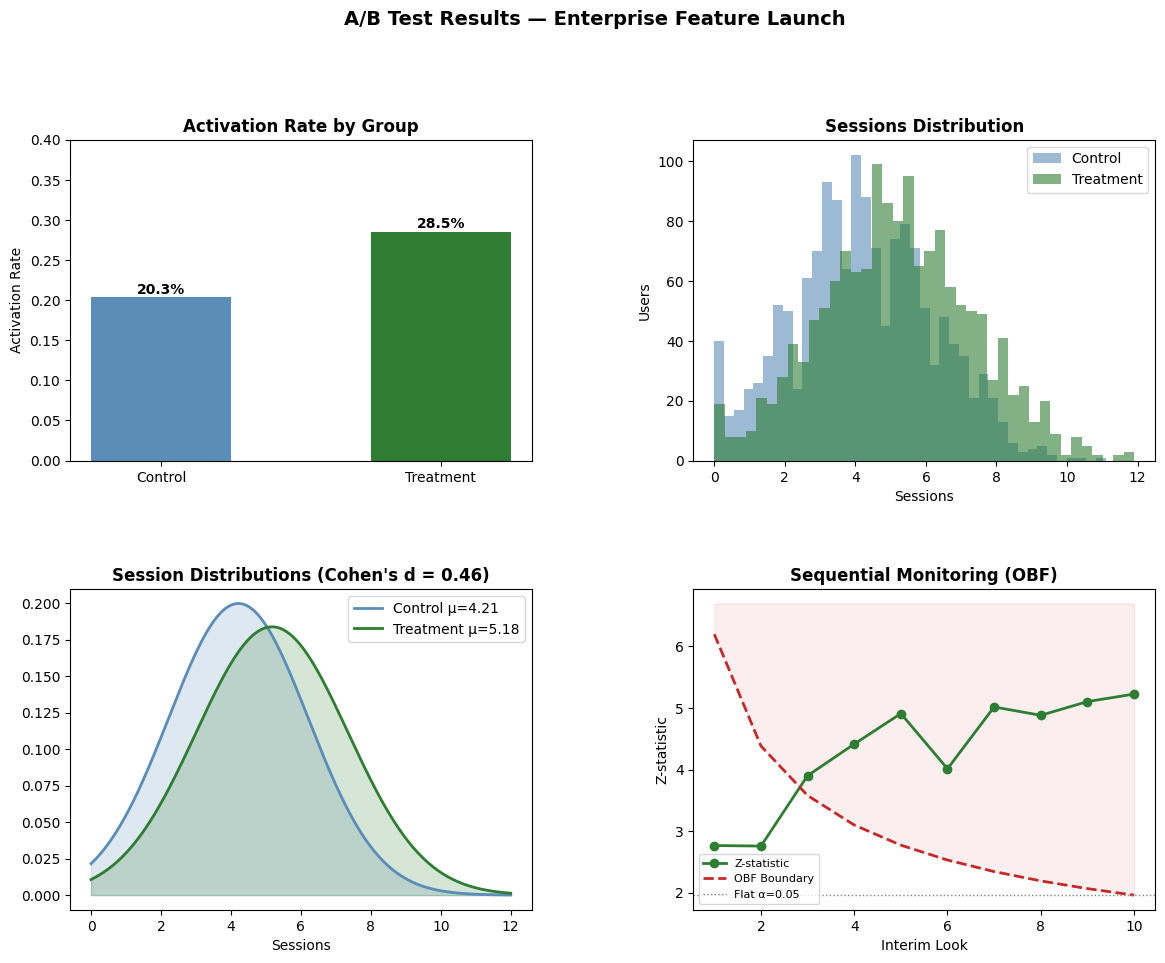

Saved to ab_test_results.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# --- Plot 1: Activation rates ---
ax1 = fig.add_subplot(gs[0, 0])
groups = ['Control', 'Treatment']
rates = [ctrl['activated'].mean(), treat['activated'].mean()]
colors = ['#5B8DB8', '#2E7D32']
bars = ax1.bar(groups, rates, color=colors, width=0.5)
ax1.set_title('Activation Rate by Group', fontweight='bold')
ax1.set_ylabel('Activation Rate')
ax1.set_ylim(0, 0.4)
for bar, rate in zip(bars, rates):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{rate:.1%}', ha='center', fontweight='bold')

# --- Plot 2: Sessions distribution ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(ctrl['sessions'], bins=40, alpha=0.6, color='#5B8DB8', label='Control')
ax2.hist(treat['sessions'], bins=40, alpha=0.6, color='#2E7D32', label='Treatment')
ax2.set_title('Sessions Distribution', fontweight='bold')
ax2.set_xlabel('Sessions')
ax2.set_ylabel('Users')
ax2.legend()

# --- Plot 3: Cohen's d visual ---
ax3 = fig.add_subplot(gs[1, 0])
x = np.linspace(0, 12, 300)
from scipy.stats import norm as sp_norm
ctrl_dist = sp_norm.pdf(x, ctrl['sessions'].mean(), ctrl['sessions'].std())
treat_dist = sp_norm.pdf(x, treat['sessions'].mean(), treat['sessions'].std())
ax3.plot(x, ctrl_dist, color='#5B8DB8', linewidth=2, label=f"Control μ={ctrl['sessions'].mean():.2f}")
ax3.plot(x, treat_dist, color='#2E7D32', linewidth=2, label=f"Treatment μ={treat['sessions'].mean():.2f}")
ax3.fill_between(x, ctrl_dist, alpha=0.2, color='#5B8DB8')
ax3.fill_between(x, treat_dist, alpha=0.2, color='#2E7D32')
ax3.set_title(f"Session Distributions (Cohen's d = {cohens_d:.2f})", fontweight='bold')
ax3.set_xlabel('Sessions')
ax3.legend()

# --- Plot 4: Sequential monitoring ---
ax4 = fig.add_subplot(gs[1, 1])
looks = seq_results['look'].tolist()
z_stats = seq_results['z_stat'].tolist()
boundaries = seq_results['boundary'].tolist()
ax4.plot(looks, z_stats, 'o-', color='#2E7D32', linewidth=2, label='Z-statistic')
ax4.plot(looks, boundaries, '--', color='#C62828', linewidth=2, label='OBF Boundary')
ax4.axhline(y=1.96, color='gray', linestyle=':', linewidth=1, label='Flat α=0.05')
ax4.fill_between(looks, boundaries,
                 max(max(z_stats), max(boundaries)) + 0.5,
                 alpha=0.08, color='#C62828')
ax4.set_title('Sequential Monitoring (OBF)', fontweight='bold')
ax4.set_xlabel('Interim Look')
ax4.set_ylabel('Z-statistic')
ax4.legend(fontsize=8)

plt.suptitle('A/B Test Results — Enterprise Feature Launch', 
             fontsize=14, fontweight='bold', y=1.01)

plt.savefig('ab_test_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to ab_test_results.png")